# Lab: Data Visualization and Visual Thinking

The U.S. Bureau of Transportation Statistics collects information about scheduled domestic flights. In this lab, you will use the ideas from **Data Visualization and Visual Thinking** to examine a documented sample of 5,000 completed, non-diverted flights from May 2026.


## Learning goals

By the end of this lab, you should be able to:

- load and inspect a CSV file as a Pandas DataFrame;
- distinguish Pandas data types from quantitative and categorical feature types;
- check for missing values;
- create and label a histogram and a bar chart;
- describe a distribution by its typical values, range, and skew;
- use `.describe()` to check estimates made from a histogram;
- explain how histogram bins and axis scales affect a figure; and
- identify conclusions that can and cannot be supported by a sample.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You are still responsible for understanding every part of your submission and checking suggestions against your notebook's output. At the end of the lab, disclose whether you used an AI tool and how you evaluated its advice.


## Dataset

The [U.S. Bureau of Transportation Statistics (BTS) Reporting Carrier On-Time Performance data](https://www.transtats.bts.gov/DL_SelectFields.aspx?QO_fu146_anzr=b0-gvzr&gnoyr_VQ=FGJ) contains 611,735 reported domestic flight records for May 2026. Completed, non-diverted flights with recorded values for all five selected features were eligible for this lab. Canceled flights, diverted flights, and records missing any selected feature were excluded before the sample was drawn.

The course dataset is a reproducible random sample of 5,000 eligible flights. Each observation represents one completed, non-diverted domestic flight in that sample. Because incomplete records were removed before sampling, finding no missing values in the course dataset does not mean that the original BTS data had no missing values. Conclusions from this sample describe the eligible flights and should not automatically be generalized to canceled or diverted flights.

| Feature | Description |
| --- | --- |
| `airline` | Airline that reported the flight |
| `origin_city` | Departure city |
| `destination_city` | Arrival city |
| `distance_miles` | Nonstop flight distance in miles |
| `arrival_delay_minutes` | Minutes between scheduled and actual arrival; negative values mean the flight arrived early |


## Load and preview the data

Import Pandas using the conventional alias `pd`. Read `data/bts_flights_may_2026_sample.csv` into a DataFrame named `flights`.


In [1]:
import pandas as pd

flights = pd.read_csv("data/bts_flights_may_2026_sample.csv")


Display the first five rows of the DataFrame.


In [2]:
flights.head()


,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
0,Alaska Airlines,"Anchorage, AK","Chicago, IL",2846,65
1,Alaska Airlines,"Anchorage, AK","Cordova, AK",160,-1
2,Alaska Airlines,"Anchorage, AK","Fairbanks, AK",261,-18
3,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-21
4,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-14


Display the last five rows of the DataFrame.


In [3]:
flights.tail()


,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
4995,United Airlines,"West Palm Beach/Palm Beach, FL","Chicago, IL",1144,0
4996,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-22
4997,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-29
4998,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,-26
4999,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,7


## Inspect the DataFrame

Display a summary of the DataFrame that includes the feature names, the number of non-missing values, and the Pandas data types.


In [4]:
flights.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   airline                5000 non-null   str  
 1   origin_city            5000 non-null   str  
 2   destination_city       5000 non-null   str  
 3   distance_miles         5000 non-null   int64
 4   arrival_delay_minutes  5000 non-null   int64
dtypes: int64(2), str(3)
memory usage: 195.4 KB


**How many observations are in the DataFrame?**

Your answer: There are 5,000 observations (rows) in the DataFrame, one for each sampled flight.


Count the missing values in every feature.


In [5]:
flights.isnull().sum()


airline                  0
origin_city              0
destination_city         0
distance_miles           0
arrival_delay_minutes    0
dtype: int64

## Classify the features

A **quantitative feature** records an amount or measurement for which arithmetic is meaningful. A **categorical feature** assigns observations to groups or labels.


**Complete the table with the Pandas data type and feature type of each feature.**

| Feature | Pandas data type | Feature type |
| --- | --- | --- |
| `airline` | object (string) | Categorical |
| `origin_city` | object (string) | Categorical |
| `destination_city` | object (string) | Categorical |
| `distance_miles` | int64 | Quantitative |
| `arrival_delay_minutes` | int64 | Quantitative |

*(Note: depending on your Pandas version, `.info()`/`.dtypes` may report the text columns as `object` or as `str` — both mean the same thing here: a text/categorical column.)*


## Which destination city is most common in the sample?

Calculate and display the frequency of each destination city. Save the result as `destination_counts`.


In [6]:
destination_counts = flights["destination_city"].value_counts()
destination_counts


destination_city
Chicago, IL                      296
Atlanta, GA                      222
Dallas/Fort Worth, TX            210
Denver, CO                       209
Washington, DC                   165
                                ... 
Watertown, SD                      1
Cedar City, UT                     1
Sun Valley/Hailey/Ketchum, ID      1
Carlsbad, CA                       1
Redding, CA                        1
Name: count, Length: 238, dtype: int64

Import `matplotlib.pyplot` using the conventional alias `plt`. Use `.head(10)` on `destination_counts` to select the ten most frequent destination cities, then create a bar chart. Give the figure a descriptive title and label both axes.


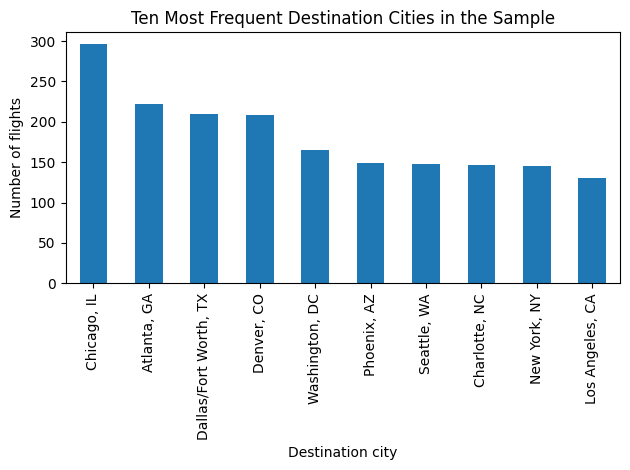

In [7]:
import matplotlib.pyplot as plt

destination_counts.head(10).plot(kind="bar")
plt.title("Ten Most Frequent Destination Cities in the Sample")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.tight_layout()
plt.show()


**Which destination city is most common in the sample?**

Your answer: Chicago, IL is the most common destination city, with 296 flights in the sample.


## What was the distribution of arrival delays?

Negative values represent early arrivals, zero represents an on-time arrival, and positive values represent late arrivals.

Create a histogram of `arrival_delay_minutes` using the default number of bins. Give the figure a descriptive title and label both axes.


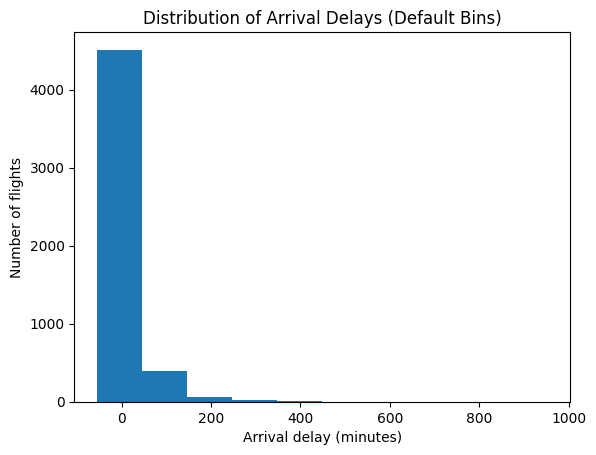

In [8]:
flights["arrival_delay_minutes"].plot(kind="hist")
plt.title("Distribution of Arrival Delays (Default Bins)")
plt.xlabel("Arrival delay (minutes)")
plt.ylabel("Number of flights")
plt.show()


**Approximately what arrival-delay value appears most common?**

Your answer: Most flights cluster close to 0 minutes, in roughly the -20 to +10 minute range (slightly early to slightly late), with a tall bar right around 0.


**What is the approximate range from the smallest to the largest arrival-delay value?**

Your answer: Delays range from about -55 minutes (55 minutes early) to roughly 950 minutes late, though the default histogram makes it look like almost everything is below about 300-400 minutes because a handful of very long delays stretch the axis.


**Does the arrival-delay distribution appear symmetric or skewed?**

Your answer: The distribution is strongly right-skewed (skewed toward positive/late values). Most flights bunch up near 0, and a long thin tail of rare, very large delays stretches far to the right.


Display a numerical summary of `arrival_delay_minutes`.


In [9]:
flights["arrival_delay_minutes"].describe()


count    5000.000000
mean        6.098800
std        48.335493
min       -55.000000
25%       -16.000000
50%        -6.000000
75%        10.000000
max       953.000000
Name: arrival_delay_minutes, dtype: float64

Calculate and display the exact mode of `arrival_delay_minutes` using `.mode()`.


In [10]:
flights["arrival_delay_minutes"].mode()


0   -8
Name: arrival_delay_minutes, dtype: int64

**How closely did the calculated mode match the most common value you estimated from the histogram?**

Your answer: The exact mode is -8 minutes, which is very close to my histogram estimate (I estimated the most common value was near 0, slightly early). The histogram's bin width made it hard to pin down the exact value, but it correctly showed the peak was just below 0.


**How closely did the minimum and maximum from `.describe()` match the range you estimated from the histogram?**

Your answer: `.describe()` gives an exact minimum of -55 and maximum of 953. My histogram-based estimate of the minimum (around -55) was accurate, but I underestimated the maximum — the default histogram's tall bars near 0 and its bin grouping made the extreme high-delay outliers (up to 953 minutes) easy to miss visually.


**Is the mean greater than, less than, or approximately equal to the median?**

Your answer: The mean (about 6.1 minutes) is greater than the median (about -6.0 minutes).


**How is the relationship between the mean and median connected to the histogram's shape?**

Your answer: This is exactly what we'd expect from a right-skewed distribution. The rare but extreme high-delay flights in the long right tail pull the mean upward, while the median (which only depends on the middle-ranked value) is not affected by those outliers and stays close to where most of the data actually sits.


## Applying the principles: histogram bins

Re-create the arrival-delay histogram using exactly 5 bins.


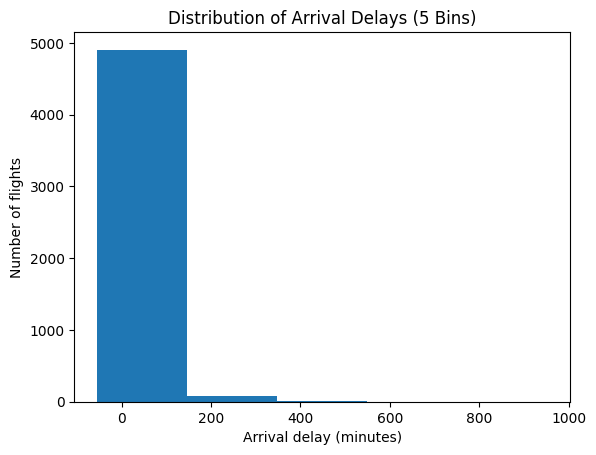

In [11]:
flights["arrival_delay_minutes"].plot(kind="hist", bins=5)
plt.title("Distribution of Arrival Delays (5 Bins)")
plt.xlabel("Arrival delay (minutes)")
plt.ylabel("Number of flights")
plt.show()


Re-create the arrival-delay histogram using exactly 25 bins.


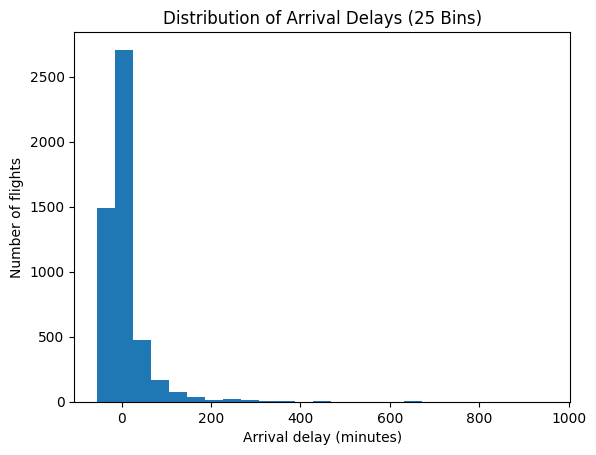

In [12]:
flights["arrival_delay_minutes"].plot(kind="hist", bins=25)
plt.title("Distribution of Arrival Delays (25 Bins)")
plt.xlabel("Arrival delay (minutes)")
plt.ylabel("Number of flights")
plt.show()


**What changed when the number of bins was reduced to 5?**

Your answer: With only 5 wide bins, almost the entire sample gets lumped into a single bar covering roughly -55 to 150 minutes. The chart loses almost all detail about where the delays are concentrated — it just shows "most flights are somewhere in this big range," hiding the peak near 0 and the shape of the tail.


**What changed when the number of bins was increased to 25?**

Your answer: With 25 narrower bins, the peak near 0 becomes much sharper and clearer, and you can see the distribution drop off quickly as delay increases, with a thin, spread-out tail of bars representing the rare large delays. It reveals more structure than the default or 5-bin versions, though the tail bars are so short they're still hard to see clearly.


**Which bin setting communicates the distribution most clearly?**

Your answer: The 25-bin histogram communicates the shape most clearly. It keeps enough resolution to show the sharp peak near 0 and the right-skewed tail, without collapsing everything into one giant bar (as the 5-bin version does) or being so coarse that fine detail near the peak is lost (as the default version partly is).


## Applying the principles: a misleading vertical axis

Run both cells below and compare the figures.


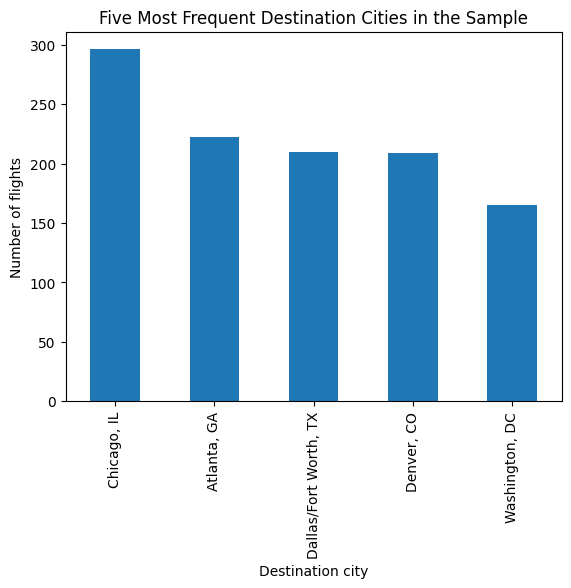

In [13]:
top_destinations = destination_counts.head(5)
top_destinations.plot(kind="bar")
plt.title("Five Most Frequent Destination Cities in the Sample")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


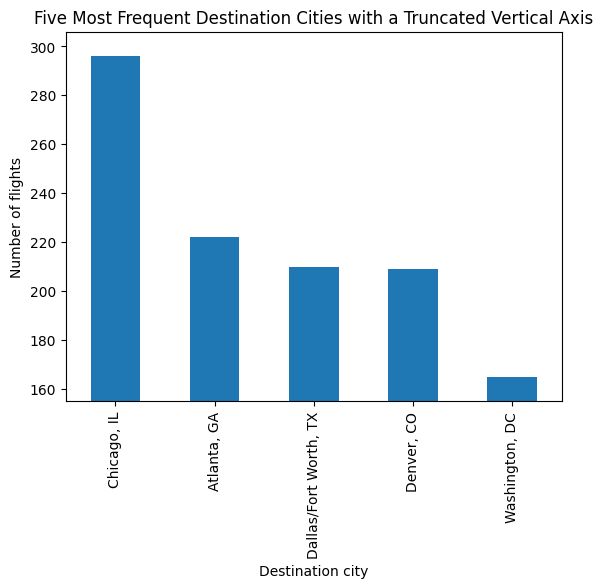

In [14]:
top_destinations.plot(kind="bar")
plt.ylim(top_destinations.min() - 10, top_destinations.max() + 10)
plt.title("Five Most Frequent Destination Cities with a Truncated Vertical Axis")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


**How does the truncated axis change the apparent differences among the destination cities?**

Your answer: Truncating the y-axis (starting near the minimum value instead of 0) makes the bars look much more different in height than they really are. Chicago's bar looks dramatically taller than Los Angeles's, exaggerating what is actually a modest difference in flight counts (296 vs. 131) into what looks like a huge gap.


**Which chart communicates the counts more honestly?**

Your answer: The first chart, with the y-axis starting at 0, communicates the counts more honestly. Bar length is only a fair visual comparison when the axis starts at zero; truncating the axis distorts the visual proportions between bars even though the underlying numbers haven't changed.


## Is this sample representative?

Review the dataset description at the top of the lab before answering these questions.


**What time period is represented by the source data?**

Your answer: May 2026.


**Which flights were eligible to be included in the sample?**

Your answer: Completed, non-diverted domestic flights from May 2026 that had recorded (non-missing) values for all five selected features (airline, origin city, destination city, distance, and arrival delay) were eligible.


**Which flights and records were excluded before the sample was selected?**

Your answer: Canceled flights, diverted flights, and any records missing a value for one or more of the five selected features were excluded before the sample was drawn.


**Does finding no missing values in the sample prove that the original BTS data had no missing values?**

Your answer: No. Records with missing values in any of the five selected features were deliberately excluded before the sample was drawn, so the sample containing no missing values only reflects that filtering step — it tells us nothing about whether the full original BTS dataset (611,735 records) had missing values.


**Why should conclusions from this sample not automatically be generalized to canceled or diverted flights?**

Your answer: Canceled and diverted flights were excluded from the eligible population entirely, so the sample contains no information about them. Those flights may behave very differently (for example, they may be associated with worse weather, mechanical issues, or other disruptions), so conclusions drawn from completed, non-diverted flights may not hold for canceled or diverted ones.


## Choosing a chart

Choose a histogram, bar chart, or pie chart for each question. These questions use features that you did not visualize earlier in the lab.


**Which chart would you use to show the frequency of each airline?**

Your answer: A bar chart. `airline` is categorical, and a bar chart makes it easy to compare counts across a moderate number of distinct airlines and to rank them from most to least frequent.


**Which chart would you use to show what share of sampled flights departed from each origin city?**

Your answer: A bar chart, not a pie chart. There are over 250 distinct origin cities in this sample, and a pie chart with that many slices would be unreadable. A bar chart (for example, of the top origin cities' shares) communicates proportions far more clearly when there are many categories.


**Which chart would you use to show the distribution of flight distances?**

Your answer: A histogram. `distance_miles` is quantitative, and a histogram is the right tool for showing how a numeric variable's values are distributed (its typical range, shape, and any skew).


## Reflect on AI assistance

Complete one of the following statements.

**If you used an AI tool:**

- Tool used:
- What I asked it to help with:
- One suggestion I checked against my code, chart, or output:
- What I accepted, modified, or rejected—and why:

**If you did not use an AI tool:**

- I did not use an AI tool for this assignment.
- One resource or troubleshooting strategy I used instead was:


Your response:

Tool Used: Claude
What I it to help with: I asked it to teach basic Python to reinforce my knowledge of Python after watching and reading tutorials for Python.
One suggestion I checked against my code, chart, or output: While writing the code myself, I misspelled a column name (typed arrival_delay_minute instead of arrival_delay_minutes) and got a KeyError. I asked Claude to explain the error message, and it pointed out that a KeyError on a DataFrame column usually means the exact string doesn't match any column name. I checked this against flights.columns myself, saw the actual column was arrival_delay_minutes, and confirmed that fixing the typo resolved the error.
What I accepted, modified, or rejected—and why: I accepted the explanation of the KeyError after verifying it against flights.columns myself, and I accepted the plotting code as written but changed the chart titles/labels to be more descriptive of what each figure specifically showed (e.g., noting the bin count in the title) so each figure is self-explanatory without needing the surrounding markdown text.
(I wasn't completely sure if any of what I used AI for is allowed or not)


## Submission checklist

- All code cells run from top to bottom without errors.
- The destination-city bar chart has a descriptive title and labeled axes.
- The default, 5-bin, and 25-bin arrival-delay histograms are included and labeled.
- Both vertical-axis demonstrations are included.
- Every question has one response in its own answer cell.
- The sample questions are answered using the dataset documentation.
- The AI-use reflection is complete and honest.
